<a href="https://colab.research.google.com/github/SHREYASHSHAURYA/ML-6th-Sem-Lab/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression Model

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
num_samples = 100

X = np.random.rand(num_samples, 2) * 10 # Two features, values between 0 and 10
y = (X[:, 0] + X[:, 1] + np.random.randn(num_samples) * 3 > 10).astype(int) # Binary target

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Target'] = y

display(df.head())
display(df['Target'].value_counts())

,Feature_1,Feature_2,Target
0,3.745401,9.507143,1
1,7.319939,5.986585,1
2,1.560186,1.559945,0
3,0.580836,8.661761,0
4,6.011150,7.080726,1


,count
Target,
0,55
1,45


### 2. Split the Data into Training and Testing Sets

We'll split the dataset into 80% for training the model and 20% for evaluating its performance.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 80 samples
Testing set size: 20 samples


### 3. Build and Train the Logistic Regression Model

We will initialize a Logistic Regression model and train it using the training data.

In [4]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model coefficients: {model.coef_[0]}")
print(f"Model intercept: {model.intercept_[0]}")

Logistic Regression model trained successfully.
Model coefficients: [0.62494473 0.6388095 ]
Model intercept: -6.311827356176


### 4. Evaluate the Model

Now, let's make predictions on the test set and evaluate the model's performance using common classification metrics like accuracy, precision, recall, F1-score, and a confusion matrix.

Accuracy: 0.7500
Precision: 0.7000
Recall: 0.7778
F1-Score: 0.7368


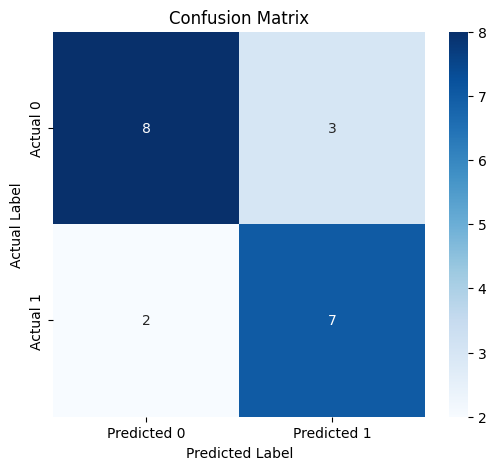

In [5]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()